# VDP vs digest2 — ROC Comparison

Head-to-head comparison of the VDP probability-map classifier vs digest2 on the same S3M objects. The current comparison uses the May 9 NEOCP VDP map geometry: a circular sky patch centered at geocentric ecliptic `(lon, lat) = (229°, 0°)` with radius `30°`, epoch `2026-05-09T22:00:00`, and Rubin Observatory/X05 two-point 30-minute tracklets for digest2.

**Fast path (recommended):** Run section 2 onward — loads the pre-computed parquet.

**Full re-run:** Run `run_digest2_comparison.py` first. The script propagates the S3M populations, scores VDP, runs digest2 in chunks, and writes the parquet used here.


In [1]:
# Optional: re-run the full pipeline from this notebook (slow)
# The script now chunks digest2 calls, so the full run can take about an hour.
# %run run_digest2_comparison.py


## 1. Setup

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src'))
import velocity_density_pipeline as vdp

_HERE = os.path.abspath('.')
RUN_LABEL = '2026-05-09T22_neocp'
PARQUET = os.path.join(_HERE, f's3m_digest2_comparison_{RUN_LABEL}.parquet')
PROB_MAPS = os.path.join(_HERE, f'prob_maps_{RUN_LABEL}.npz')
FIG_OUT  = os.path.join(_HERE, f'roc_comparison_vdp_digest2_{RUN_LABEL}.png')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

In [19]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src'))
import velocity_density_pipeline as vdp

_HERE = os.path.abspath('.')
RUN_LABEL = '2026-05-09_antisun_minus_120'
PARQUET = os.path.join(_HERE, f's3m_digest2_comparison_{RUN_LABEL}.parquet')
PROB_MAPS = os.path.join(_HERE, f'prob_maps_{RUN_LABEL}.npz')
FIG_OUT  = os.path.join(_HERE, f'roc_comparison_vdp_digest2_{RUN_LABEL}.png')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 2. Load results

In [20]:
df = pd.read_parquet(PARQUET)
print(f'{len(df):,} objects')
print(df['true_population'].value_counts().to_string())

pops = sorted(df['true_population'].unique())
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}
df.head()

17,964 objects
true_population
MBA        8049
TNO        7894
NEO        1404
Trojans     617


,true_population,lam_deg,vlam,vbeta,mag_app,H,P_NEO_vdp,P_NEO_d2
0,NEO,104.350466,0.468022,0.115560,15.915101,11.869,0.000000,0.18
1,NEO,125.831430,0.187210,0.017647,18.248003,12.312,0.002477,0.32
2,NEO,87.373099,0.219724,-0.035594,19.426087,12.538,0.001317,0.27
3,NEO,103.886500,0.369645,0.019753,18.319901,12.895,0.000260,0.15
4,NEO,96.029570,0.388061,-0.048146,18.595926,13.232,0.000518,0.04


In [21]:
# Re-score VDP from the probability maps (in case you want fresh scores)
pm = vdp.ProbMapSet.from_npz(PROB_MAPS)
probs = pm.score_visible(df.vlam.to_numpy(), df.vbeta.to_numpy(), df.mag_app.to_numpy())
df['P_NEO_vdp'] = probs['NEO']
df['P_MBA_vdp'] = probs['MBA']
df['P_TNO_vdp'] = probs['TNO']
df['P_Troj_vdp'] = probs['Trojans']
print('VDP P_NEO range:', round(float(df.P_NEO_vdp.min()), 4), '–', round(float(df.P_NEO_vdp.max()), 4))
print('sum check (should be ≤1):', (df.P_NEO_vdp + df.P_MBA_vdp + df.P_TNO_vdp + df.P_Troj_vdp).describe())

VDP P_NEO range: 0.0 – 0.9808
sum check (should be ≤1): count    17964.000000
mean         0.998700
std          0.018447
min          0.329492
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64


## 3. Score distributions

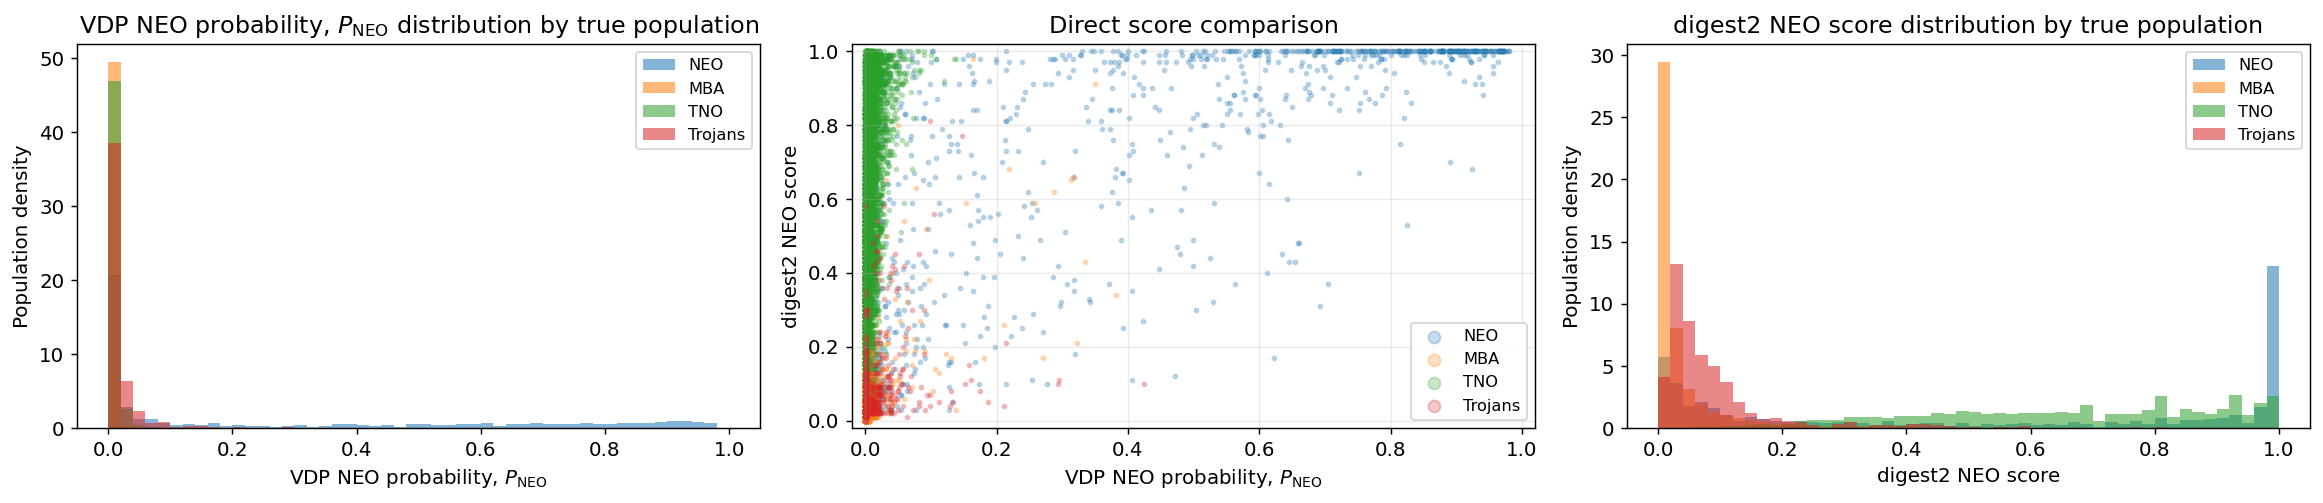

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
pops = ['NEO', 'MBA', 'TNO', 'Trojans']
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}

hist_specs = [
    (axes[0], 'P_NEO_vdp', 'VDP NEO probability, $P_{\mathrm{NEO}}$'),
    (axes[2], 'P_NEO_d2', 'digest2 NEO score'),
]

for ax, col, label in hist_specs:
    for pop in pops:
        sub = df.loc[df.true_population == pop, col]
        ax.hist(sub, bins=50, alpha=0.55, label=pop, color=colors.get(pop),
                density=True, range=(0, 1))
    ax.set_xlabel(label)
    ax.set_ylabel('Population density')
    ax.set_title(f'{label} distribution by true population')
    ax.legend(fontsize=9)

ax = axes[1]
for pop in pops:
    sub = df[df.true_population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=5, alpha=0.25,
               label=pop, color=colors.get(pop), rasterized=True)
ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('Direct score comparison')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.show()
plt.close(fig)

## 4. ROC curves

In [23]:
is_neo = (df['true_population'] == 'NEO').to_numpy()
N_neo  = is_neo.sum()
N_non  = (~is_neo).sum()
print(f'N_NEO={N_neo}  N_non-NEO={N_non}')

thresholds = np.linspace(0, 1, 401)

def compute_roc(scores, is_neo, thresholds):
    comp = np.empty(len(thresholds))
    cont = np.empty(len(thresholds))
    for j, t in enumerate(thresholds):
        above = scores > t
        tp = above[is_neo].sum()
        fp = above[~is_neo].sum()
        comp[j] = tp / max(N_neo, 1)
        cont[j] = fp / max(tp + fp, 1)
    return comp, cont

def best_f1(comp, cont, thr):
    pur = 1 - cont
    f1  = np.where(pur + comp > 0, 2*pur*comp/(pur + comp + 1e-12), 0.0)
    i   = np.argmax(f1)
    return thr[i], comp[i], cont[i], f1[i]

comp_v, cont_v = compute_roc(df['P_NEO_vdp'].to_numpy(), is_neo, thresholds)
comp_d, cont_d = compute_roc(df['P_NEO_d2'].to_numpy(),  is_neo, thresholds)

tv, cv, nv, fv = best_f1(comp_v, cont_v, thresholds)
td, cd, nd, fd = best_f1(comp_d, cont_d, thresholds)

print(f'VDP     best: t={tv:.3f}  completeness={cv:.1%}  contamination={nv:.1%}  F1={fv:.3f}')
print(f'Digest2 best: t={td:.3f}  completeness={cd:.1%}  contamination={nd:.1%}  F1={fd:.3f}')

N_NEO=1404  N_non-NEO=16560
VDP     best: t=0.060  completeness=50.5%  contamination=11.5%  F1=0.643
Digest2 best: t=0.960  completeness=28.4%  contamination=58.1%  F1=0.339


Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/roc_comparison_vdp_digest2_2026-05-09_antisun_minus_120.png


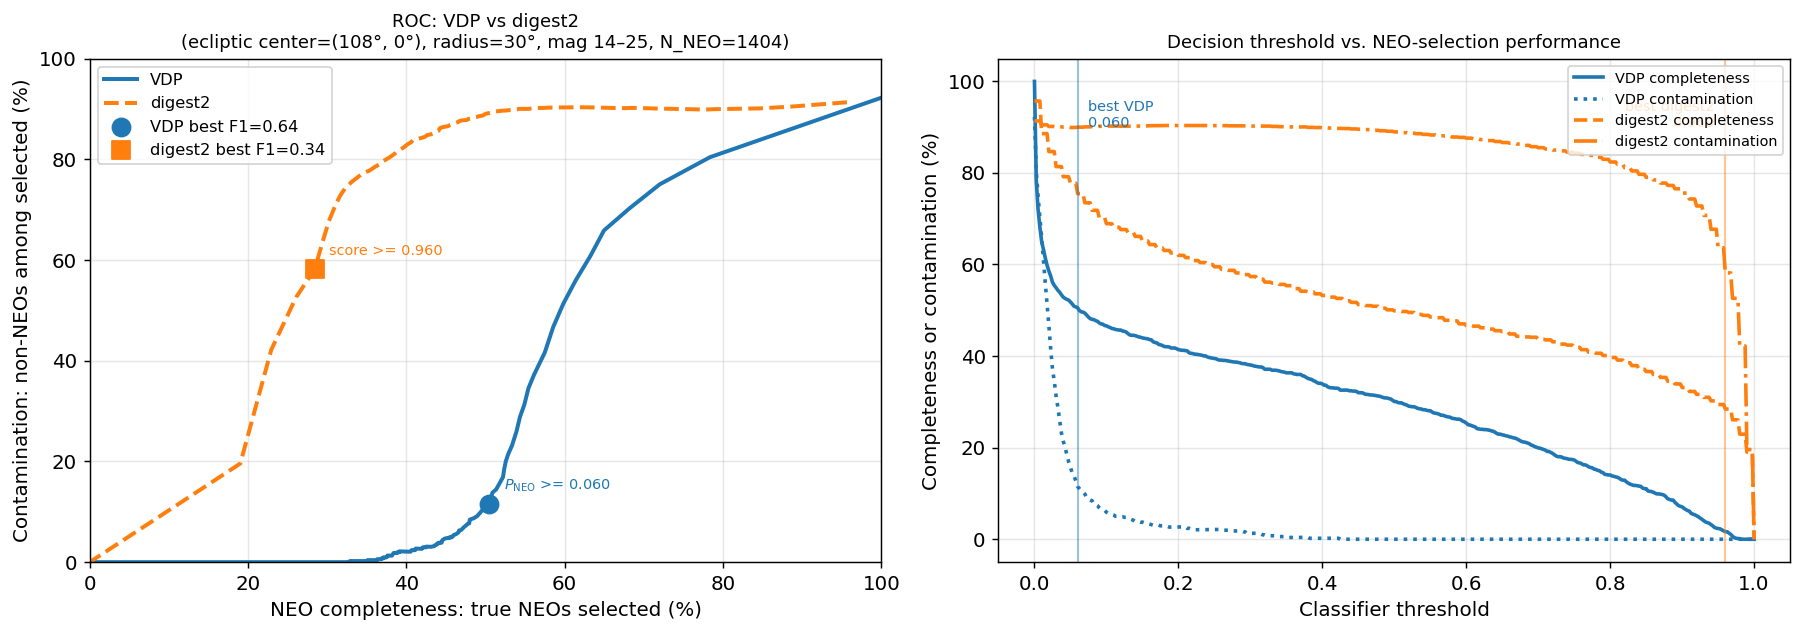

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(comp_v*100, cont_v*100, lw=2.2, color='tab:blue', label='VDP')
ax.plot(comp_d*100, cont_d*100, lw=2.2, color='tab:orange', linestyle='--', label='digest2')
ax.scatter([cv*100], [nv*100], color='tab:blue', s=100, zorder=5, label=f'VDP best F1={fv:.2f}')
ax.scatter([cd*100], [nd*100], color='tab:orange', s=100, zorder=5, marker='s', label=f'digest2 best F1={fd:.2f}')
ax.annotate(f'$P_{{\mathrm{{NEO}}}}$ >= {tv:.3f}', xy=(cv*100, nv*100), xytext=(8, 8),
            textcoords='offset points', color='tab:blue', fontsize=8)
ax.annotate(f'score >= {td:.3f}', xy=(cd*100, nd*100), xytext=(8, 8),
            textcoords='offset points', color='tab:orange', fontsize=8)
ax.set_xlabel('NEO completeness: true NEOs selected (%)')
ax.set_ylabel('Contamination: non-NEOs among selected (%)')
ax.set_title(f'ROC: VDP vs digest2\n(ecliptic center=({pm.center_lon_deg:.0f}°, {pm.center_lat_deg:.0f}°), radius={pm.max_sep_deg:.0f}°, mag 14–25, N_NEO={N_neo})', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
ax.plot(thresholds, comp_v*100, lw=2, color='tab:blue', label='VDP completeness')
ax.plot(thresholds, cont_v*100, lw=2, color='tab:blue', linestyle=':', label='VDP contamination')
ax.plot(thresholds, comp_d*100, lw=2, color='tab:orange', linestyle='--', label='digest2 completeness')
ax.plot(thresholds, cont_d*100, lw=2, color='tab:orange', linestyle='-.', label='digest2 contamination')
ax.axvline(tv, color='tab:blue', alpha=0.45, lw=1.2)
ax.axvline(td, color='tab:orange', alpha=0.45, lw=1.2)
ax.text(tv + 0.015, 96, f'best VDP\n{tv:.3f}', color='tab:blue', fontsize=8, va='top')
ax.text(td - 0.015, 96, f'best digest2\n{td:.3f}', color='tab:orange', fontsize=8, va='top', ha='right')
ax.set_xlabel('Classifier threshold')
ax.set_ylabel('Completeness or contamination (%)')
ax.set_title('Decision threshold vs. NEO-selection performance', fontsize=10)
ax.legend(fontsize=8, frameon=True, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_OUT, dpi=150, bbox_inches='tight')
print(f'Saved: {FIG_OUT}')
plt.show()
plt.close(fig)

## 5. Score-threshold quadrants

The direct score comparison becomes more useful if we draw the best-F1 decision thresholds from the ROC section. These four quadrants show where VDP and digest2 agree, and where each classifier uniquely selects candidates.

true_population,MBA,NEO,TNO,Trojans,total,NEO fraction
score_quadrant,,,,,,
both select,1,388,12,0,401,96.8%
VDP only,31,321,13,35,400,80.2%
digest2 only,1,25,708,0,734,3.4%
neither selects,8016,670,7161,582,16429,4.1%


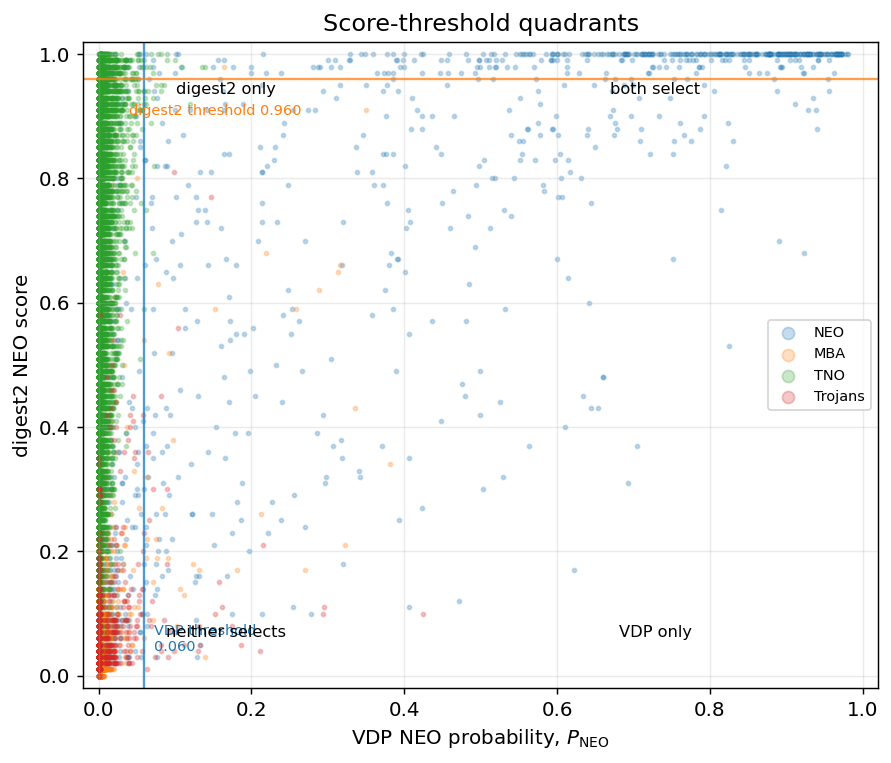

In [25]:
vdp_selected = df['P_NEO_vdp'] >= tv
d2_selected = df['P_NEO_d2'] >= td

quadrant_labels = np.select(
    [
        vdp_selected & d2_selected,
        vdp_selected & ~d2_selected,
        ~vdp_selected & d2_selected,
    ],
    [
        'both select',
        'VDP only',
        'digest2 only',
    ],
    default='neither selects',
)

quad_df = df.assign(score_quadrant=quadrant_labels)
quad_summary = (
    quad_df
    .groupby(['score_quadrant', 'true_population'])
    .size()
    .unstack(fill_value=0)
    .reindex(['both select', 'VDP only', 'digest2 only', 'neither selects'])
)
quad_summary['total'] = quad_summary.sum(axis=1)
quad_summary['NEO fraction'] = quad_summary.get('NEO', 0) / quad_summary['total']
display(quad_summary.style.format({'NEO fraction': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(7, 6))
for pop in pops:
    sub = df[df.true_population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=5, alpha=0.25,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue', lw=1.3, alpha=0.75)
ax.axhline(td, color='tab:orange', lw=1.3, alpha=0.75)
ax.text(tv + 0.012, 0.04, f'VDP threshold\n{tv:.3f}', color='tab:blue', fontsize=8)
ax.text(0.04, td - 0.04, f'digest2 threshold {td:.3f}', color='tab:orange', fontsize=8, va='top')

ax.text(0.72, 0.92, 'both select', transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.72, 0.08, 'VDP only', transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.92, 'digest2 only', transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.08, 'neither selects', transform=ax.transAxes, fontsize=9, ha='center')

ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('Score-threshold quadrants')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, markerscale=3, loc='center right')
plt.tight_layout()
plt.show()
plt.close(fig)

### Log-log score-threshold quadrants

The linear quadrant plot hides most of the structure near zero. This version uses log-scaled axes and clips exact zero scores to a small plotting floor so low-score objects remain visible.

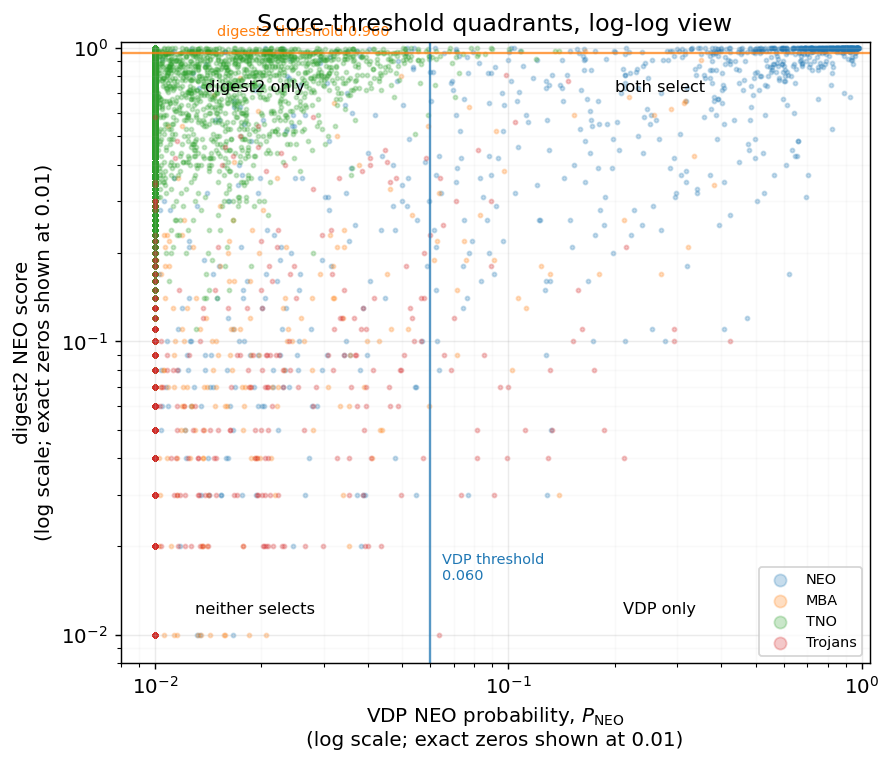

In [26]:
score_floor = 1e-2

x_log = np.clip(df['P_NEO_vdp'].to_numpy(), score_floor, 1.0)
y_log = np.clip(df['P_NEO_d2'].to_numpy(),  score_floor, 1.0)

fig, ax = plt.subplots(figsize=(7, 6))
for pop in pops:
    mask = (df.true_population == pop).to_numpy()
    ax.scatter(x_log[mask], y_log[mask], s=5, alpha=0.25,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue', lw=1.3, alpha=0.75)
ax.axhline(td, color='tab:orange', lw=1.3, alpha=0.75)
ax.text(tv * 1.08, score_floor * 1.5, f'VDP threshold\n{tv:.3f}',
        color='tab:blue', fontsize=8, va='bottom')
ax.text(score_floor * 1.5, td * 1.12, f'digest2 threshold {td:.3f}',
        color='tab:orange', fontsize=8, va='bottom')

ax.text(0.72, 0.92, 'both select',    transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.72, 0.08, 'VDP only',       transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.92, 'digest2 only',   transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.08, 'neither selects',transform=ax.transAxes, fontsize=9, ha='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(score_floor * 0.8, 1.05)
ax.set_ylim(score_floor * 0.8, 1.05)
ax.set_xlabel(f'VDP NEO probability, $P_{{\\mathrm{{NEO}}}}$\n(log scale; exact zeros shown at {score_floor:g})')
ax.set_ylabel(f'digest2 NEO score\n(log scale; exact zeros shown at {score_floor:g})')
ax.set_title('Score-threshold quadrants, log-log view')
ax.grid(alpha=0.25, which='major')
ax.grid(alpha=0.07, which='minor')
ax.legend(fontsize=8, markerscale=3, loc='lower right')

plt.tight_layout()
plt.show()
plt.close(fig)

### Population-visible square log-log quadrant view

The `1e-2` display floor makes the plot compact but hides the TNO/Trojan structure by clipping too aggressively. This version keeps a lower score floor and plots NEOs first, then the non-NEO populations on top, so the distant-population disagreement region remains visible.

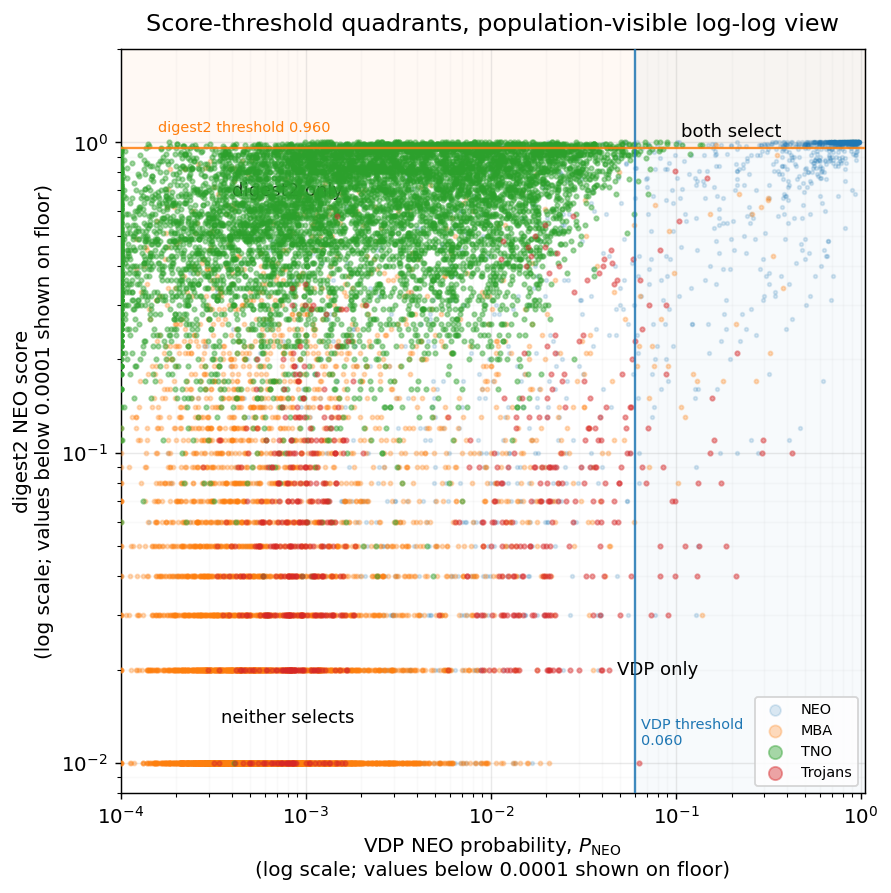

In [27]:
score_floor_visible = 1e-4
x_raw = df['P_NEO_vdp'].to_numpy()
y_raw = df['P_NEO_d2'].to_numpy()

# Poster display view: keep the population-visible score structure, but
# put exact zeros and tiny near-zero values on a single log-axis floor.
# This is display-only; thresholds, counts, and metrics above use raw scores.
x_visible = np.clip(x_raw, score_floor_visible, 1.0)
y_visible = np.clip(y_raw, score_floor_visible, 1.0)
y_low_visible = 8e-3
x_low_visible = score_floor_visible
x_high_visible = 1.05
y_high_visible = 2.0

fig, ax = plt.subplots(figsize=(7.0, 7.0))
plot_style = {
    'NEO':     dict(s=4, alpha=0.16, zorder=2),
    'MBA':     dict(s=5, alpha=0.28, zorder=3),
    'TNO':     dict(s=6, alpha=0.42, zorder=5),
    'Trojans': dict(s=6, alpha=0.42, zorder=6),
}
for pop in ['NEO', 'MBA', 'TNO', 'Trojans']:
    if pop not in pops:
        continue
    mask = df.true_population == pop
    style = plot_style[pop]
    ax.scatter(
        x_visible[mask], y_visible[mask],
        label=pop,
        color=colors.get(pop),
        rasterized=True,
        **style,
    )

ax.axvline(tv, color='tab:blue', lw=1.3, alpha=0.85, zorder=8)
ax.axhline(td, color='tab:orange', lw=1.3, alpha=0.85, zorder=8)
ax.axvspan(tv, x_high_visible, color='tab:blue', alpha=0.03, zorder=0)
ax.axhspan(td, y_high_visible, color='tab:orange', alpha=0.045, zorder=0)

ax.text(tv * 1.08, y_low_visible * 1.4, f'VDP threshold\n{tv:.3f}',
        color='tab:blue', fontsize=8, va='bottom')
ax.text(x_low_visible * 1.6, td * 1.10, f'digest2 threshold {td:.3f}',
        color='tab:orange', fontsize=8, va='bottom')

ax.text(0.20, 1.08, 'both select', fontsize=10, ha='center', va='center')
ax.text(0.08, 0.020, 'VDP only', fontsize=10, ha='center', va='center')
ax.text(8.0e-4, 0.70, 'digest2 only', fontsize=10, ha='center', va='center')
ax.text(8.0e-4, 0.014, 'neither selects', fontsize=10, ha='center', va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(x_low_visible, x_high_visible)
ax.set_ylim(y_low_visible, y_high_visible)
ax.set_box_aspect(1)
ax.set_xlabel(f'VDP NEO probability, $P_{{\\mathrm{{NEO}}}}$\n(log scale; values below {score_floor_visible:g} shown on floor)')
ax.set_ylabel(f'digest2 NEO score\n(log scale; values below {score_floor_visible:g} shown on floor)')
ax.set_title('Score-threshold quadrants, population-visible log-log view', pad=10)
ax.grid(alpha=0.28, which='major')
ax.grid(alpha=0.07, which='minor')
ax.legend(fontsize=8, markerscale=3, loc='lower right', frameon=True)

plt.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)

## 6. 2D score density

The scatter plot hides the density near zero because many objects overlap. Hexbin views show the same score space as density, first for all objects and then split into true NEO and non-NEO samples.

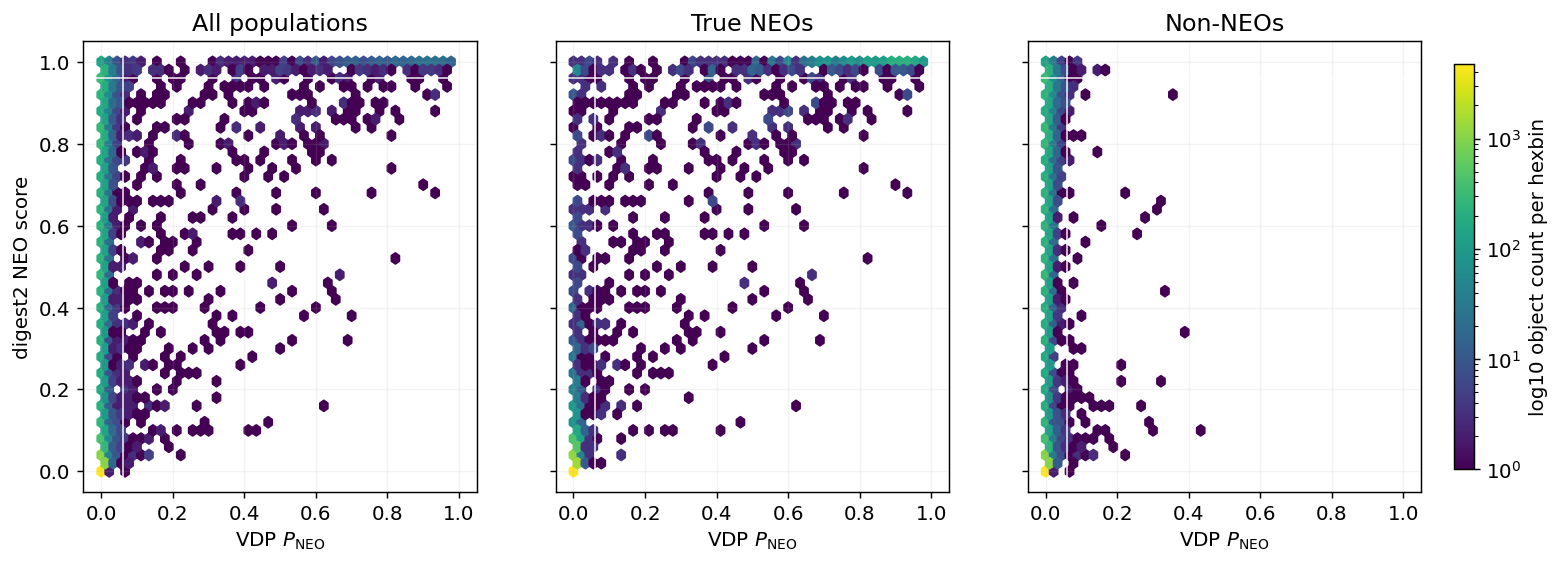

In [28]:
density_views = [
    ('All populations', np.ones(len(df), dtype=bool)),
    ('True NEOs', is_neo),
    ('Non-NEOs', ~is_neo),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for ax, (title, mask) in zip(axes, density_views):
    hb = ax.hexbin(
        df.loc[mask, 'P_NEO_vdp'],
        df.loc[mask, 'P_NEO_d2'],
        gridsize=45,
        extent=(0, 1, 0, 1),
        bins='log',
        mincnt=1,
        cmap='viridis',
    )
    ax.axvline(tv, color='white', lw=1.0, alpha=0.8)
    ax.axhline(td, color='white', lw=1.0, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('VDP $P_{\mathrm{NEO}}$')
    ax.grid(alpha=0.15)
axes[0].set_ylabel('digest2 NEO score')
cbar = fig.colorbar(hb, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label('log10 object count per hexbin')
plt.show()
plt.close(fig)

## 7. Rank comparison

Thresholds are useful, but follow-up is often rank-ordered. This view asks whether the same objects appear near the top of each classifier's candidate list.

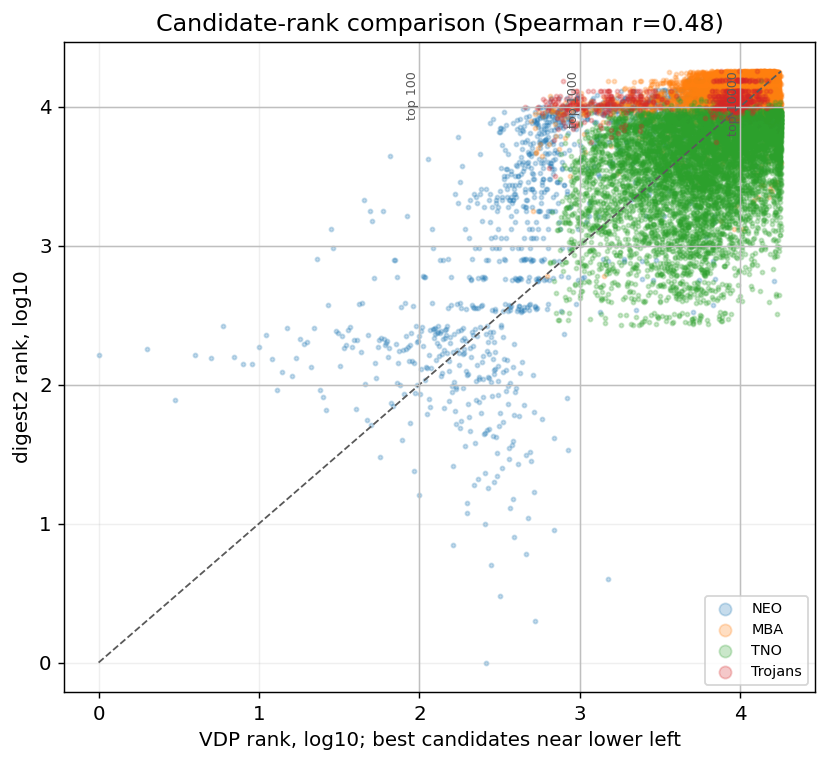

,true_population,P_NEO_vdp,P_NEO_d2,VDP rank,digest2 rank,vlam,vbeta,mag_app
0,NEO,0.000000,0.18,17948,9131,0.468022,0.115560,15.915101
1,NEO,0.002477,0.32,5647,8024,0.187210,0.017647,18.248003
2,NEO,0.001317,0.27,7531,8446,0.219724,-0.035594,19.426087
3,NEO,0.000260,0.15,15933,9358,0.369645,0.019753,18.319901
4,NEO,0.000518,0.04,12221,11060,0.388061,-0.048146,18.595926


In [29]:
rank_df = df.copy()
rank_df['VDP rank'] = rank_df['P_NEO_vdp'].rank(method='first', ascending=False).astype(int)
rank_df['digest2 rank'] = rank_df['P_NEO_d2'].rank(method='first', ascending=False).astype(int)
rank_df['log VDP rank'] = np.log10(rank_df['VDP rank'])
rank_df['log digest2 rank'] = np.log10(rank_df['digest2 rank'])

spearman = rank_df[['P_NEO_vdp', 'P_NEO_d2']].corr(method='spearman').iloc[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for pop in pops:
    sub = rank_df[rank_df.true_population == pop]
    ax.scatter(sub['log VDP rank'], sub['log digest2 rank'], s=5, alpha=0.25,
               label=pop, color=colors.get(pop), rasterized=True)

max_log_rank = np.log10(len(rank_df))
ax.plot([0, max_log_rank], [0, max_log_rank], color='0.35', lw=1, linestyle='--')
for n in [100, 1000, 10000]:
    if n <= len(rank_df):
        r = np.log10(n)
        ax.axvline(r, color='0.75', lw=0.8)
        ax.axhline(r, color='0.75', lw=0.8)
        ax.text(r, max_log_rank, f'top {n}', fontsize=7, rotation=90, va='top', ha='right', color='0.35')

ax.set_xlabel('VDP rank, log10; best candidates near lower left')
ax.set_ylabel('digest2 rank, log10')
ax.set_title(f'Candidate-rank comparison (Spearman r={spearman:.2f})')
ax.legend(fontsize=8, markerscale=3, loc='lower right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close(fig)

rank_df[['true_population', 'P_NEO_vdp', 'P_NEO_d2', 'VDP rank', 'digest2 rank', 'vlam', 'vbeta', 'mag_app']].head()

## 8. Top-N follow-up yield

This is the observer-facing version of the comparison: if we can follow up only the top-ranked candidates, how many true NEOs do we recover and how contaminated is that follow-up list?

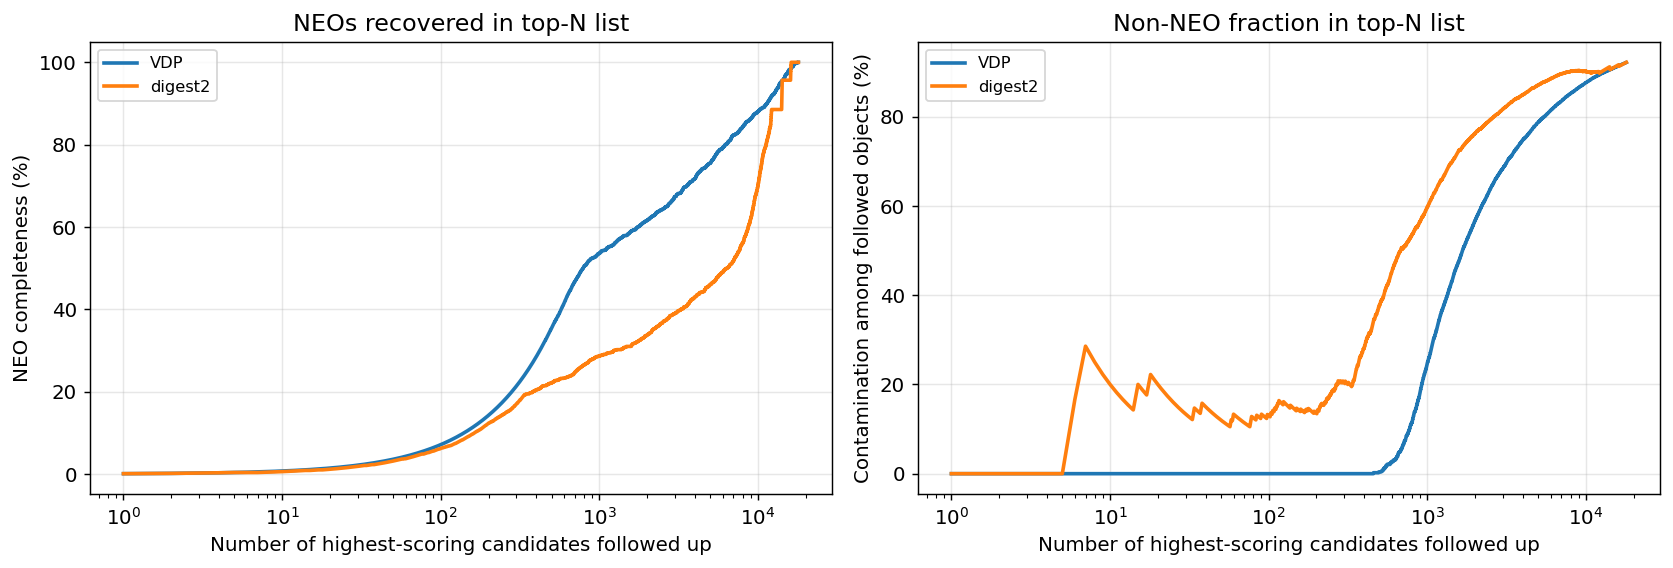

neo_recovered         completeness_pct         contamination_pct  \
classifier           VDP digest2              VDP digest2               VDP   
n_followed                                                                    
50                  50.0    44.0             3.56    3.13              0.00   
100                100.0    87.0             7.12    6.20              0.00   
250                250.0   204.0            17.81   14.53              0.00   
500                498.0   311.0            35.47   22.15              0.40   
1000               752.0   402.0            53.56   28.63             24.80   
2500               902.0   516.0            64.25   36.75             63.92   
5000              1060.0   646.0            75.50   46.01             78.80   

                    
classifier digest2  
n_followed          
50           12.00  
100          13.00  
250          18.40  
500          37.80  
1000         59.80  
2500         79.36  
5000         87.08

In [30]:
def followup_curve(score_col, label):
    ordered = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    selected = np.arange(1, len(ordered) + 1)
    neo_cum = (ordered.true_population == 'NEO').cumsum().to_numpy()
    completeness = neo_cum / N_neo
    contamination = 1 - (neo_cum / selected)
    return pd.DataFrame({
        'n_followed': selected,
        'neo_recovered': neo_cum,
        'completeness': completeness,
        'contamination': contamination,
        'classifier': label,
    })

followup = pd.concat([
    followup_curve('P_NEO_vdp', 'VDP'),
    followup_curve('P_NEO_d2', 'digest2'),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for label, color in [('VDP', 'tab:blue'), ('digest2', 'tab:orange')]:
    sub = followup[followup.classifier == label]
    axes[0].plot(sub.n_followed, sub.completeness * 100, color=color, lw=2, label=label)
    axes[1].plot(sub.n_followed, sub.contamination * 100, color=color, lw=2, label=label)

for ax in axes:
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_xlabel('Number of highest-scoring candidates followed up')
axes[0].set_ylabel('NEO completeness (%)')
axes[0].set_title('NEOs recovered in top-N list')
axes[1].set_ylabel('Contamination among followed objects (%)')
axes[1].set_title('Non-NEO fraction in top-N list')
plt.tight_layout()
plt.show()
plt.close(fig)

summary_n = [50, 100, 250, 500, 1000, 2500, 5000]
summary_n = [n for n in summary_n if n <= len(df)]
followup_summary = (
    followup[followup.n_followed.isin(summary_n)]
    .assign(completeness_pct=lambda x: x.completeness * 100,
            contamination_pct=lambda x: x.contamination * 100)
    .pivot(index='n_followed', columns='classifier', values=['neo_recovered', 'completeness_pct', 'contamination_pct'])
)
display(followup_summary.round(2))

## 9. Live NEOCP published-score context

This optional section pulls the current MPC NEO Confirmation Page table and displays its **published MPC score** values. It does **not** compare those live candidates to VDP or to the synthetic benchmark distribution, because that would imply an apples-to-apples scoring run that we have not done here.

The live NEOCP RA/Dec, magnitude, and discovery times are not propagated to `2026-05-09T22:00:00`, and they are not looked up in the VDP probability maps. A direct VDP-vs-NEOCP test needs candidate ephemerides or tracklets at a chosen epoch, sky-plane rates in the VDP coordinate frame, apparent magnitude, and matching probability maps for the relevant epoch/field geometry.

In [31]:
NEOCP_URL = 'https://minorplanetcenter.net/iau/NEO/toconfirm_tabular.html'

try:
    neocp_tables = pd.read_html(NEOCP_URL)
    neocp = max(neocp_tables, key=len).copy()
    neocp.columns = [str(c).strip() for c in neocp.columns]

    score_col = next((c for c in neocp.columns if 'score' in c.lower()), None)
    if score_col is None:
        raise ValueError(f'Could not find a score column. Columns found: {list(neocp.columns)}')

    neocp['MPC NEOCP score raw'] = pd.to_numeric(neocp[score_col], errors='coerce')
    neocp = neocp.dropna(subset=['MPC NEOCP score raw']).copy()
    scale = 100.0 if neocp['MPC NEOCP score raw'].max() > 1.0 else 1.0
    neocp['MPC NEOCP score 0-1'] = neocp['MPC NEOCP score raw'] / scale

    print(f'Loaded {len(neocp):,} current NEOCP rows from {NEOCP_URL}')
    print(f'Using score column: {score_col!r}; scale divisor: {scale:g}')
    print('Note: these are MPC-published NEOCP scores only; no VDP scoring or propagation to 2026-05-09T22:00:00 is performed here.')
    display(neocp.head(10))
    display(neocp['MPC NEOCP score 0-1'].describe().to_frame('current MPC-published NEOCP score'))
except Exception as exc:
    neocp = pd.DataFrame()
    print('NEOCP live fetch skipped or failed.')
    print(f'{type(exc).__name__}: {exc}')

Loaded 19 current NEOCP rows from https://minorplanetcenter.net/iau/NEO/toconfirm_tabular.html
Using score column: 'Score'; scale divisor: 100
Note: these are MPC-published NEOCP scores only; no VDP scoring or propagation to 2026-05-09T22:00:00 is performed here.


,Temp Desig,Score,Discovery,R.A.,Decl.,V,Updated,Note,NObs,Arc,H,Not Seen/dys,MPC NEOCP score raw,MPC NEOCP score 0-1
0,C1EYRR5,100.0,2026 05 23.4,15 51.9,+02 45,22.6,Updated May 23.48 UT,NaN,10.0,0.09,25.3,0.491,100.0,1.00
2,C1EYQL5,100.0,2026 05 23.4,15 53.3,+01 34,22.3,Updated May 23.48 UT,NaN,7.0,0.09,24.2,0.488,100.0,1.00
4,C1EYPU5,97.0,2026 05 23.4,15 49.3,+02 57,22.9,Updated May 23.49 UT,NaN,6.0,0.07,22.4,0.506,97.0,0.97
6,C1EYPT5,100.0,2026 05 23.4,15 49.8,+02 23,21.8,Updated May 23.79 UT,NaN,14.0,0.08,24.3,0.495,100.0,1.00
8,C1EYD55,66.0,2026 05 23.3,15 48.9,-12 58,22.1,Updated May 23.41 UT,NaN,10.0,0.06,19.4,0.566,66.0,0.66
10,C1EXH55,100.0,2026 05 23.3,13 58.5,+05 10,22.3,Updated May 23.37 UT,NaN,10.0,0.08,23.3,0.594,100.0,1.00
12,6EM3521,86.0,2026 05 23.1,13 11.1,-12 28,20.0,Updated May 23.93 UT,NaN,22.0,0.86,22.3,0.041,86.0,0.86
14,NAOCBPP,99.0,2026 05 20.7,14 52.0,-19 21,22.1,Updated May 22.70 UT,NaN,4.0,0.13,22.4,3.106,99.0,0.99
16,CZYNHKZ,100.0,2026 05 14.4,16 22.2,+02 18,21.8,Updated May 23.35 UT,NaN,4.0,0.02,22.7,9.570,100.0,1.00
18,C46CD31,100.0,2026 05 21.4,01 06.6,-03 34,25.7,Updated May 23.35 UT,NaN,7.0,0.05,28.6,2.514,100.0,1.00


,current MPC-published NEOCP score
count,19.000000
mean,0.882632
std,0.245738
min,0.100000
25%,0.920000
50%,0.990000
75%,1.000000
max,1.000000


## 10. Per-population score breakdown

In [14]:
for pop in sorted(df.true_population.unique()):
    sub = df[df.true_population == pop]
    vdp_med = sub.P_NEO_vdp.median()
    d2_med  = sub.P_NEO_d2.median()
    vdp_hi  = (sub.P_NEO_vdp > tv).mean()
    d2_hi   = (sub.P_NEO_d2  > td).mean()
    print(f'{pop:10s}  n={len(sub):4d}  '
          f'VDP median={vdp_med:.3f}  above_thr={vdp_hi:.1%}  '
          f'| d2 median={d2_med:.3f}  above_thr={d2_hi:.1%}')

MBA         n=7749  VDP median=0.001  above_thr=1.1%  | d2 median=0.010  above_thr=0.0%
NEO         n=1149  VDP median=0.021  above_thr=55.8%  | d2 median=0.470  above_thr=26.0%
TNO         n=7703  VDP median=0.000  above_thr=0.0%  | d2 median=0.490  above_thr=4.2%
Trojans     n=14437  VDP median=0.001  above_thr=1.4%  | d2 median=0.050  above_thr=0.0%


## 11. Explore: VDP score vs. observable properties

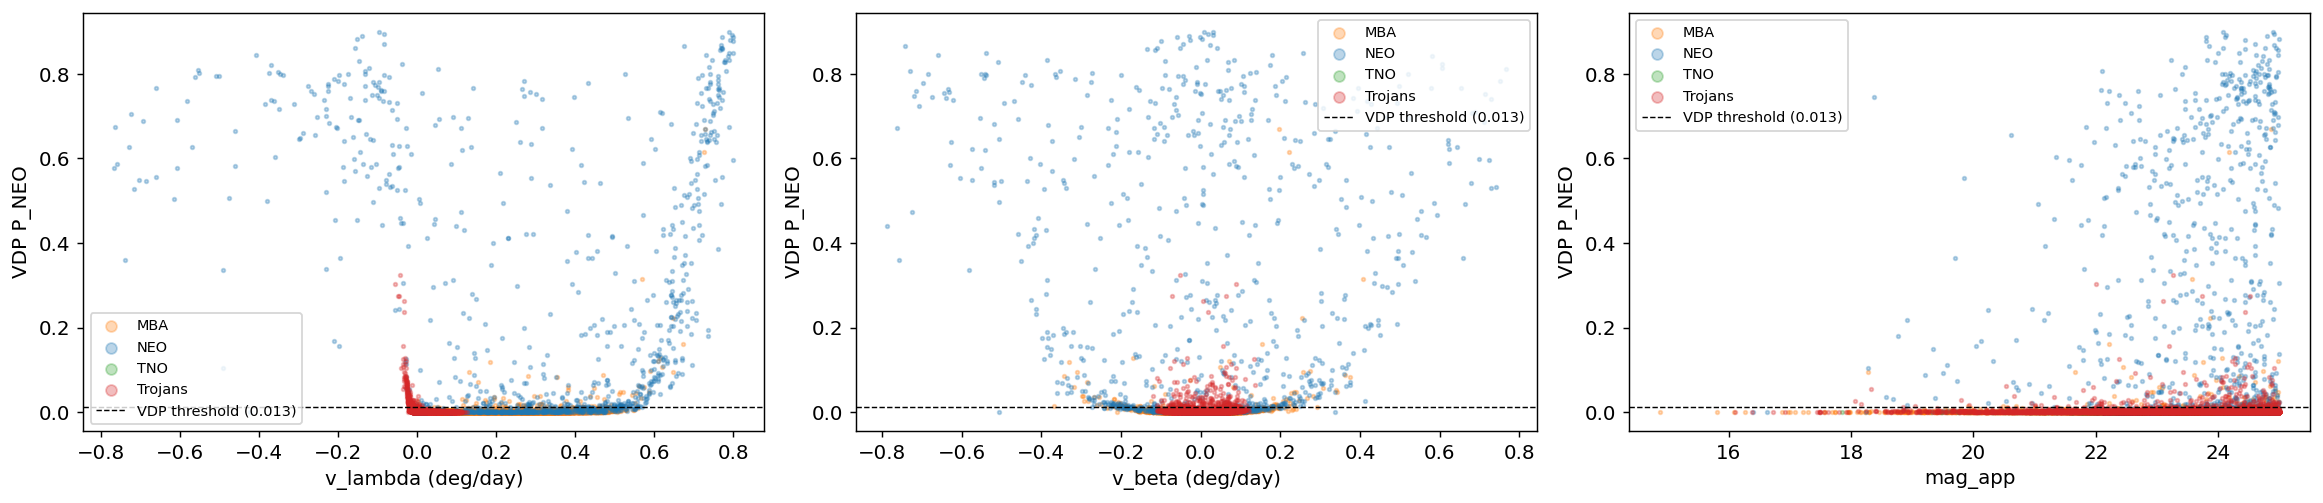

In [15]:
pops = sorted(df['true_population'].unique())
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('vbeta', 'v_beta (deg/day)'), ('mag_app', 'mag_app')]
):
    for pop in pops:
        sub = df[df.true_population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_vdp'], s=4, alpha=0.3,
                   label=pop, color=colors.get(pop))
    ax.axhline(tv, color='k', lw=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('VDP P_NEO')
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()
plt.close(fig)


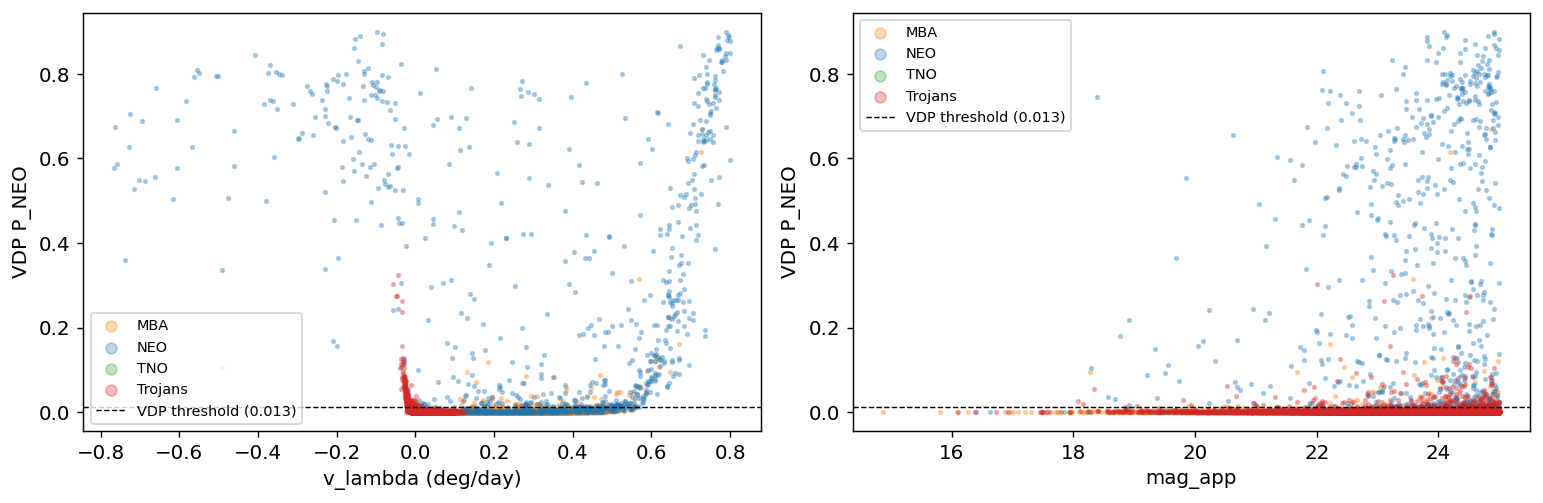

In [16]:
# Poster-friendly VDP observable view: v_lambda and magnitude only
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('mag_app', 'mag_app')]
):
    for pop in pops:
        sub = df[df.true_population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_vdp'], s=4, alpha=0.3,
                   label=pop, color=colors.get(pop))
    ax.axhline(tv, color='k', lw=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('VDP P_NEO')
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()
plt.close(fig)


### Direct score comparison

This single-panel view puts the two classifier scores against each other for the same objects. The threshold lines mark the best-F1 operating points from the ROC section.

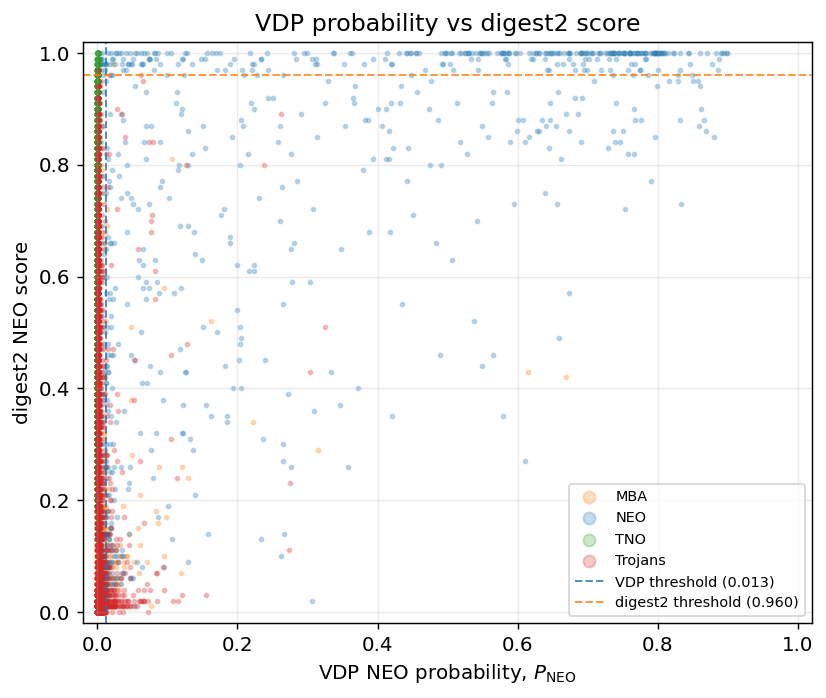

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for pop in pops:
    sub = df[df.true_population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=5, alpha=0.25,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue', lw=1.1, alpha=0.8, linestyle='--',
           label=f'VDP threshold ({tv:.3f})')
ax.axhline(td, color='tab:orange', lw=1.1, alpha=0.8, linestyle='--',
           label=f'digest2 threshold ({td:.3f})')

ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('VDP probability vs digest2 score')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, markerscale=3, loc='lower right')

plt.tight_layout()
plt.show()
plt.close(fig)

## 12. Explore: digest2 score vs. observable properties

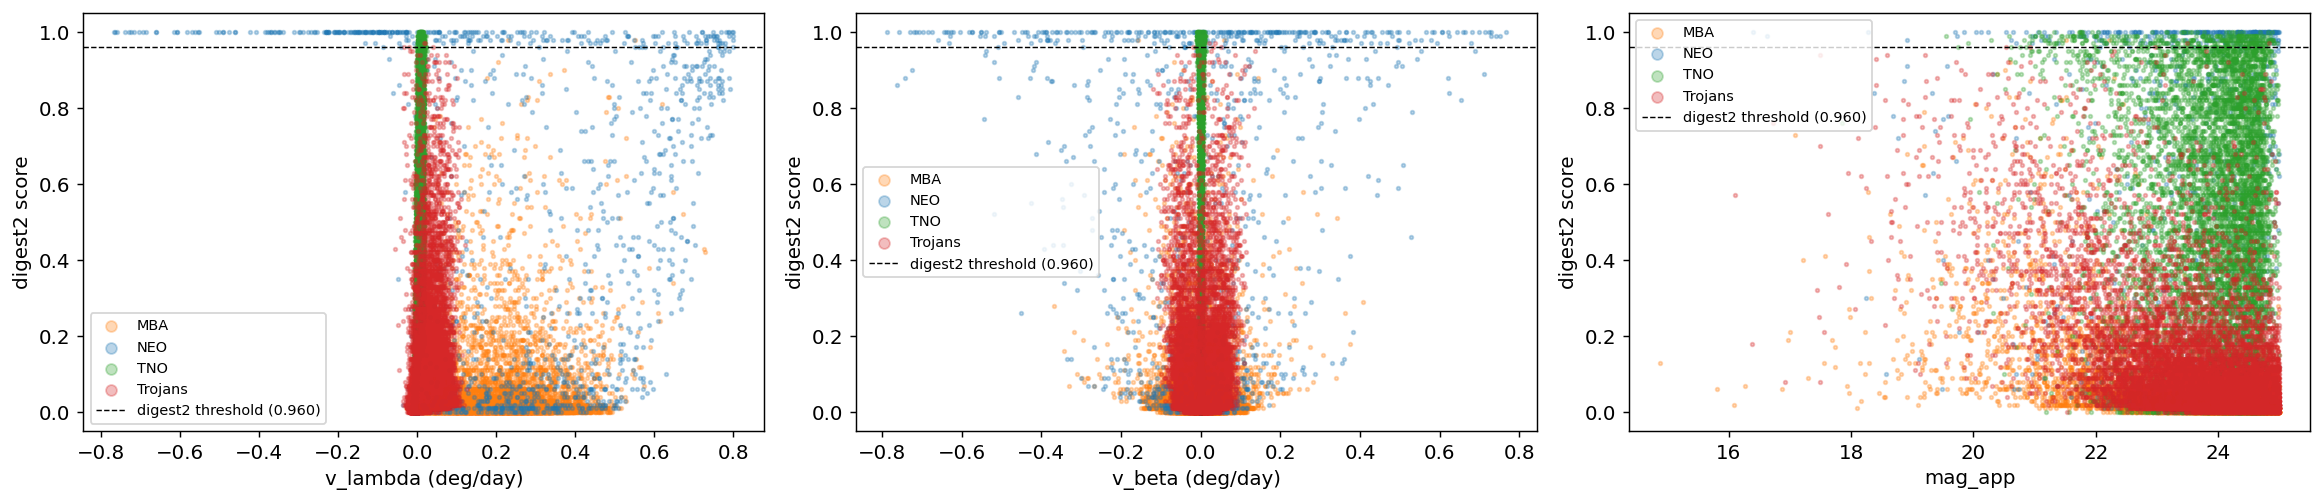

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('vbeta', 'v_beta (deg/day)'), ('mag_app', 'mag_app')]
):
    for pop in pops:
        sub = df[df.true_population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_d2'], s=4, alpha=0.3,
                   label=pop, color=colors.get(pop))
    ax.axhline(td, color='k', lw=0.8, linestyle='--', label=f'digest2 threshold ({td:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('digest2 score')
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()
plt.close(fig)